# Primetrade.ai Round-0 Analysis
## Exploring Trader Performance x Bitcoin Market Sentiment on Hyperliquid

**Datasets:**
1. **Bitcoin Fear & Greed Index** - Daily sentiment classification (Extreme Fear / Fear / Neutral / Greed / Extreme Greed)
2. **Historical Trader Data from Hyperliquid** - 211K+ trades across 32 traders and 246 coins

**Objective:** Explore the relationship between trader performance and market sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading strategies.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Dark theme for all charts
plt.rcParams.update({
    "figure.facecolor"  : "#0d1117",
    "axes.facecolor"    : "#161b22",
    "axes.edgecolor"    : "#30363d",
    "axes.labelcolor"   : "#c9d1d9",
    "xtick.color"       : "#8b949e",
    "ytick.color"       : "#8b949e",
    "text.color"        : "#c9d1d9",
    "grid.color"        : "#21262d",
    "grid.linestyle"    : "--",
    "font.family"       : "DejaVu Sans",
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 13,
    "axes.titlecolor"   : "#ffffff",
})

SENTIMENT_ORDER  = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
SENTIMENT_COLORS = {
    "Extreme Fear" : "#e63946",
    "Fear"         : "#f4a261",
    "Neutral"      : "#a8dadc",
    "Greed"        : "#52b788",
    "Extreme Greed": "#1b4332",
}
palette = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
print("Setup complete.")

Setup complete.


## 1. Data Loading & Cleaning

In [2]:
# Load datasets
fg = pd.read_csv("dataset/fear_greed_index.csv")
hd = pd.read_csv("dataset/historical_data.csv")

print(f"Fear & Greed Index: {fg.shape[0]:,} rows, {fg.shape[1]} columns")
print(f"Historical Trades:  {hd.shape[0]:,} rows, {hd.shape[1]} columns")
print()
print("=== Fear & Greed Index (first 5 rows) ===")
display(fg.head())
print()
print("=== Historical Trader Data (first 5 rows) ===")
display(hd.head())

Fear & Greed Index: 2,644 rows, 4 columns
Historical Trades:  211,224 rows, 16 columns

=== Fear & Greed Index (first 5 rows) ===


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



=== Historical Trader Data (first 5 rows) ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
# Parse dates
fg["date"] = pd.to_datetime(fg["date"])
hd["date"] = pd.to_datetime(hd["Timestamp IST"], format="%d-%m-%Y %H:%M", errors="coerce").dt.normalize()

# Rename for clarity
fg.rename(columns={"classification": "sentiment", "value": "fg_value"}, inplace=True)
fg = fg[["date", "fg_value", "sentiment"]]

# Merge on date
df = hd.merge(fg, on="date", how="inner")

# Identify closed trades (where PnL is realized)
close_mask  = df["Direction"].str.startswith("Close", na=False)
df_closed   = df[close_mask].copy()

print(f"Merged dataset:     {len(df):,} rows")
print(f"Unique traders:     {df['Account'].nunique()}")
print(f"Unique coins:       {df['Coin'].nunique()}")
print(f"Date range:         {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Closed-trade rows:  {len(df_closed):,}")
print()
print("Sentiment distribution in merged data:")
print(df["sentiment"].value_counts().reindex(SENTIMENT_ORDER))

Merged dataset:     211,218 rows
Unique traders:     32
Unique coins:       246
Date range:         2023-05-01 to 2025-05-01
Closed-trade rows:  84,685

Sentiment distribution in merged data:
sentiment
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

### 2.1 Bitcoin Fear & Greed Index Timeline

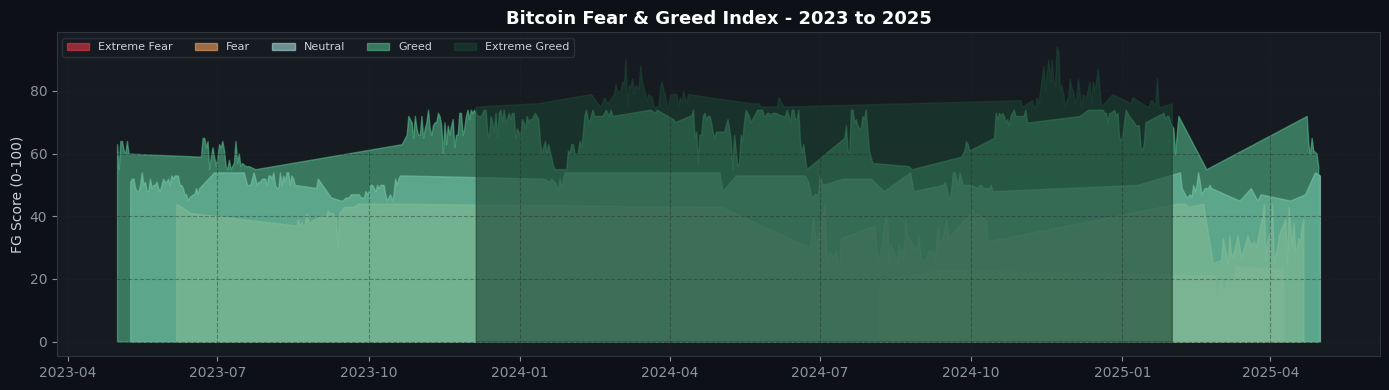


Key observation: The market oscillated between extreme fear and greed multiple times,
providing a rich dataset for studying sentiment-driven trading behavior.


In [4]:
daily_fg = fg[(fg["date"] >= "2023-05-01") & (fg["date"] <= "2025-05-01")].copy()

fig, ax = plt.subplots(figsize=(14, 4))
for sent in SENTIMENT_ORDER:
    mask = daily_fg["sentiment"] == sent
    ax.fill_between(daily_fg.loc[mask, "date"], daily_fg.loc[mask, "fg_value"],
                    alpha=0.6, label=sent, color=SENTIMENT_COLORS[sent])
ax.set_title("Bitcoin Fear & Greed Index - 2023 to 2025")
ax.set_ylabel("FG Score (0-100)")
ax.legend(loc="upper left", fontsize=8, ncol=5,
          facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nKey observation: The market oscillated between extreme fear and greed multiple times,")
print("providing a rich dataset for studying sentiment-driven trading behavior.")

### 2.2 Trading Activity Across Sentiment Regimes

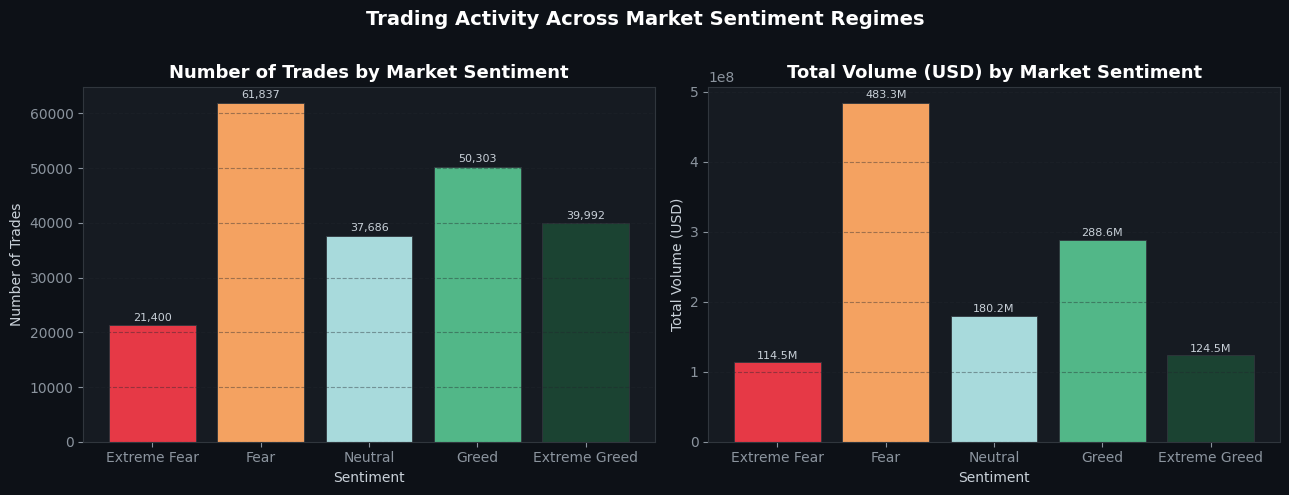


Finding: Fear days have the HIGHEST trade count (61.8K) and volume ($483M).
These top traders are actively counter-trading fear, not panicking.


In [5]:
vol_by_sent = (df.groupby("sentiment")["Size USD"]
               .agg(["sum", "count"])
               .reindex(SENTIMENT_ORDER)
               .reset_index())
vol_by_sent.columns = ["sentiment", "total_usd", "trade_count"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
                           ["trade_count", "total_usd"],
                           ["Number of Trades", "Total Volume (USD)"]):
    bars = ax.bar(vol_by_sent["sentiment"], vol_by_sent[col],
                  color=[SENTIMENT_COLORS[s] for s in vol_by_sent["sentiment"]],
                  edgecolor="#30363d", linewidth=0.6)
    ax.set_title(f"{title} by Market Sentiment")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.4)
    for bar in bars:
        h = bar.get_height()
        label = f"{h/1e6:.1f}M" if col == "total_usd" else f"{int(h):,}"
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, label,
                ha="center", va="bottom", fontsize=8, color="#c9d1d9")
plt.suptitle("Trading Activity Across Market Sentiment Regimes", fontsize=14,
             color="#ffffff", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nFinding: Fear days have the HIGHEST trade count (61.8K) and volume ($483M).")
print("These top traders are actively counter-trading fear, not panicking.")

### 2.3 Profitability by Sentiment Regime

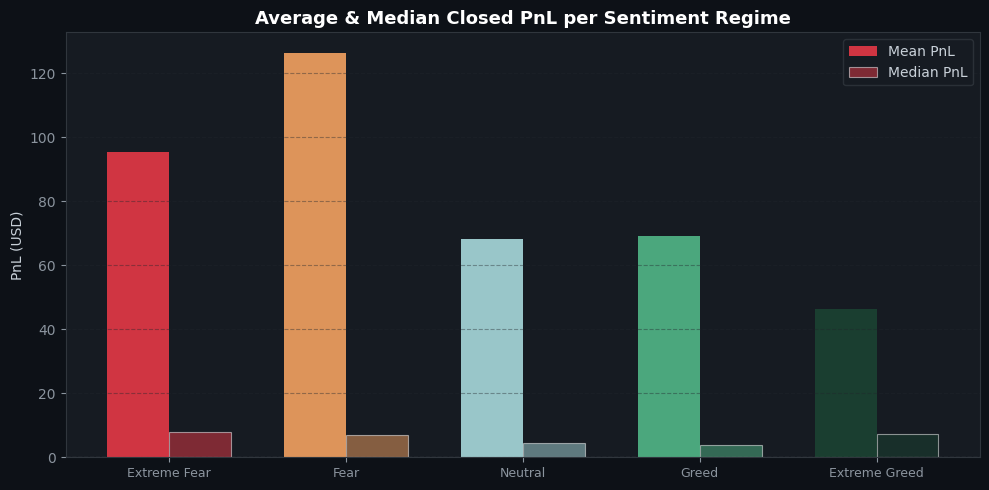


Key Insight: Fear regime yields the HIGHEST avg PnL ($126.41) -
2.7x higher than Extreme Greed ($46.23).
Contrarian entries during fear are significantly more profitable.


In [6]:
pnl_by_sent = (df_closed.groupby("sentiment")["Closed PnL"]
               .agg(["mean", "median", "std", "sum"])
               .reindex(SENTIMENT_ORDER)
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SENTIMENT_ORDER))
w = 0.35
bars_mean   = ax.bar(x - w/2, pnl_by_sent["mean"],   w, label="Mean PnL",
                     color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER], alpha=0.9)
bars_median = ax.bar(x + w/2, pnl_by_sent["median"], w, label="Median PnL",
                     color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER], alpha=0.5,
                     edgecolor="white", linewidth=0.8)
ax.axhline(0, color="#ffffff", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Average & Median Closed PnL per Sentiment Regime")
ax.set_xticks(x); ax.set_xticklabels(SENTIMENT_ORDER, fontsize=9)
ax.set_ylabel("PnL (USD)")
ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

print("\nKey Insight: Fear regime yields the HIGHEST avg PnL ($126.41) -")
print("2.7x higher than Extreme Greed ($46.23).")
print("Contrarian entries during fear are significantly more profitable.")

### 2.4 Win Rate by Sentiment

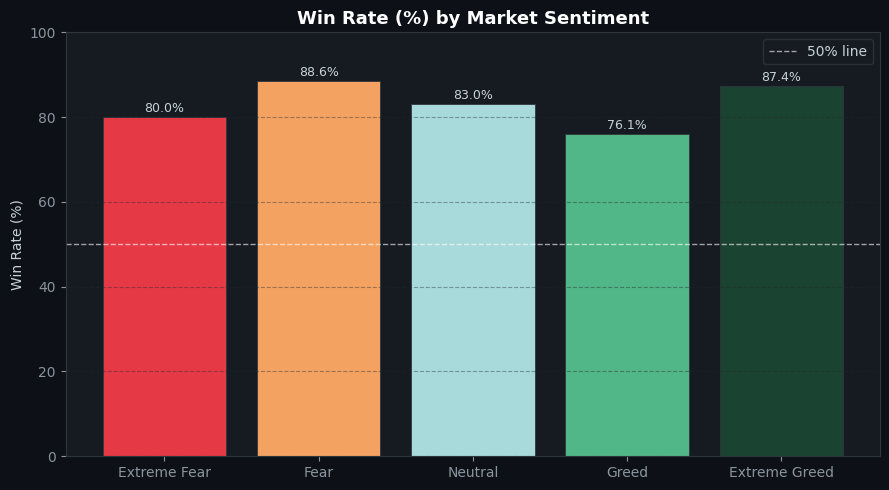


Finding: Fear has the highest win rate (88.6%), Greed the lowest (76.1%).
Overconfidence during greed may lead to riskier, less disciplined entries.


In [7]:
df_closed["win"] = df_closed["Closed PnL"] > 0
wr = (df_closed.groupby("sentiment")["win"]
      .agg(["mean", "count"])
      .reindex(SENTIMENT_ORDER)
      .reset_index())
wr.columns = ["sentiment", "win_rate", "n_trades"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(wr["sentiment"], wr["win_rate"] * 100,
              color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
              edgecolor="#30363d", linewidth=0.6)
ax.axhline(50, color="#ffffff", linewidth=1, linestyle="--", alpha=0.6, label="50% line")
ax.set_title("Win Rate (%) by Market Sentiment")
ax.set_ylabel("Win Rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)
ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
for bar, row in zip(bars, wr.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{row.win_rate*100:.1f}%",
            ha="center", va="bottom", fontsize=9, color="#c9d1d9")
plt.tight_layout()
plt.show()

print("\nFinding: Fear has the highest win rate (88.6%), Greed the lowest (76.1%).")
print("Overconfidence during greed may lead to riskier, less disciplined entries.")

### 2.5 Long vs Short Positioning by Sentiment

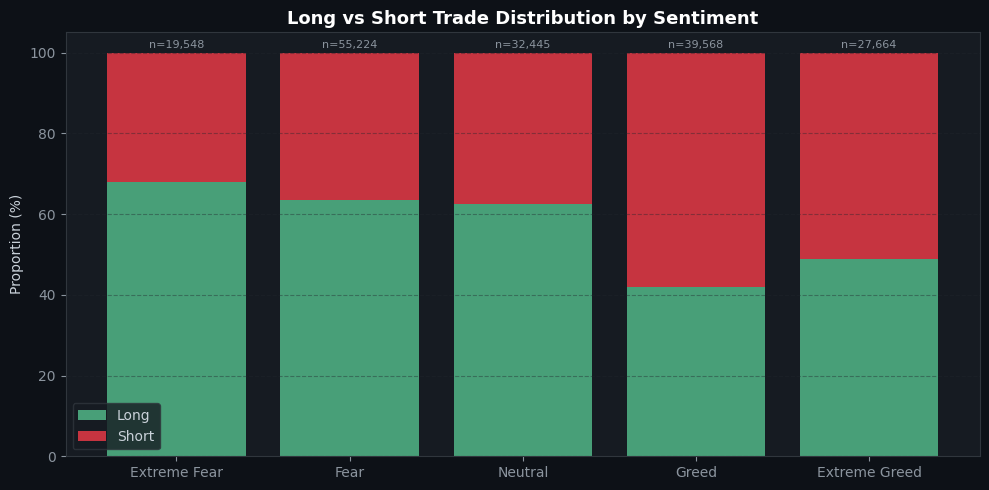


Finding: Long bias persists across ALL sentiment regimes (~55-60%).
Even top traders are structurally long-biased on Hyperliquid.


In [8]:
df["direction_simple"] = df["Direction"].apply(
    lambda x: "Long" if "Long" in str(x) else ("Short" if "Short" in str(x) else "Other"))
ls_sent = (df[df["direction_simple"].isin(["Long","Short"])]
           .groupby(["sentiment","direction_simple"])
           .size().unstack(fill_value=0)
           .reindex(SENTIMENT_ORDER))
ls_pct = ls_sent.div(ls_sent.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(SENTIMENT_ORDER))
for side, color in [("Long","#52b788"),("Short","#e63946")]:
    vals = ls_pct[side].values if side in ls_pct.columns else np.zeros(len(SENTIMENT_ORDER))
    ax.bar(SENTIMENT_ORDER, vals, bottom=bottom, label=side, color=color, alpha=0.85)
    bottom += vals
ax.set_title("Long vs Short Trade Distribution by Sentiment")
ax.set_ylabel("Proportion (%)")
ax.set_ylim(0, 105)
ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
ax.grid(axis="y", alpha=0.4)
for i, sent in enumerate(SENTIMENT_ORDER):
    ax.text(i, 101, f"n={int(ls_sent.loc[sent].sum()):,}", ha="center",
            fontsize=8, color="#8b949e")
plt.tight_layout()
plt.show()

print("\nFinding: Long bias persists across ALL sentiment regimes (~55-60%).")
print("Even top traders are structurally long-biased on Hyperliquid.")

### 2.6 Top-10 Traders - PnL Heatmap by Sentiment

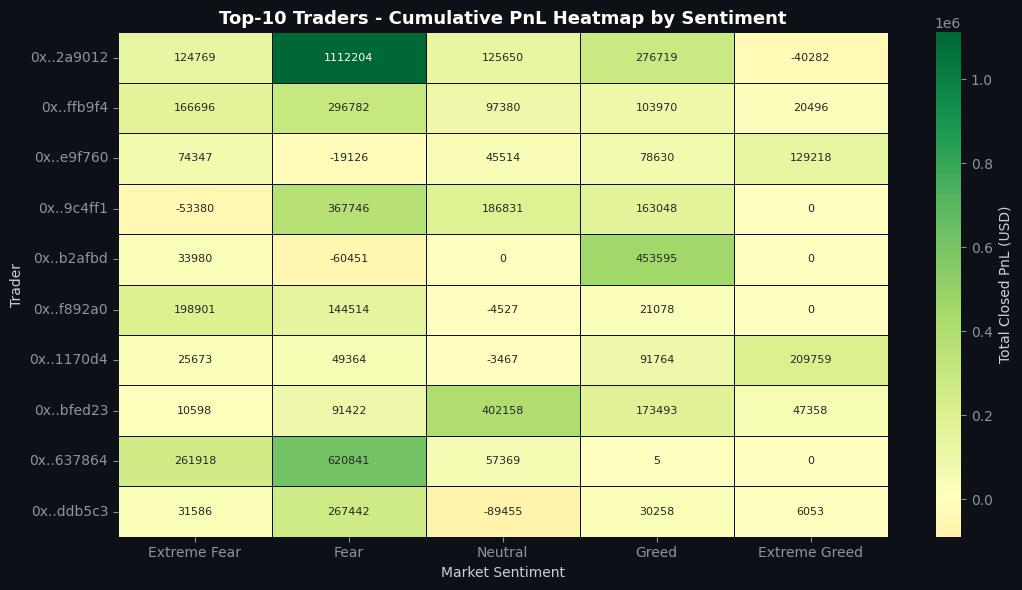


Insight: Individual trader profitability varies dramatically by sentiment.
Some traders thrive in fear while others perform better in greed.


In [9]:
top10 = (df_closed.groupby("Account")["Closed PnL"]
         .sum().nlargest(10).index.tolist())
heat_data = (df_closed[df_closed["Account"].isin(top10)]
             .groupby(["Account","sentiment"])["Closed PnL"]
             .sum().unstack(fill_value=0)[SENTIMENT_ORDER])
heat_data.index = [f"0x..{a[-6:]}" for a in heat_data.index]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(heat_data, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.5, linecolor="#0d1117",
            fmt=".0f", annot=True, annot_kws={"size":8},
            cbar_kws={"label":"Total Closed PnL (USD)"})
ax.set_title("Top-10 Traders - Cumulative PnL Heatmap by Sentiment")
ax.set_xlabel("Market Sentiment")
ax.set_ylabel("Trader")
plt.tight_layout()
plt.show()

print("\nInsight: Individual trader profitability varies dramatically by sentiment.")
print("Some traders thrive in fear while others perform better in greed.")

### 2.7 Fee Analysis by Sentiment

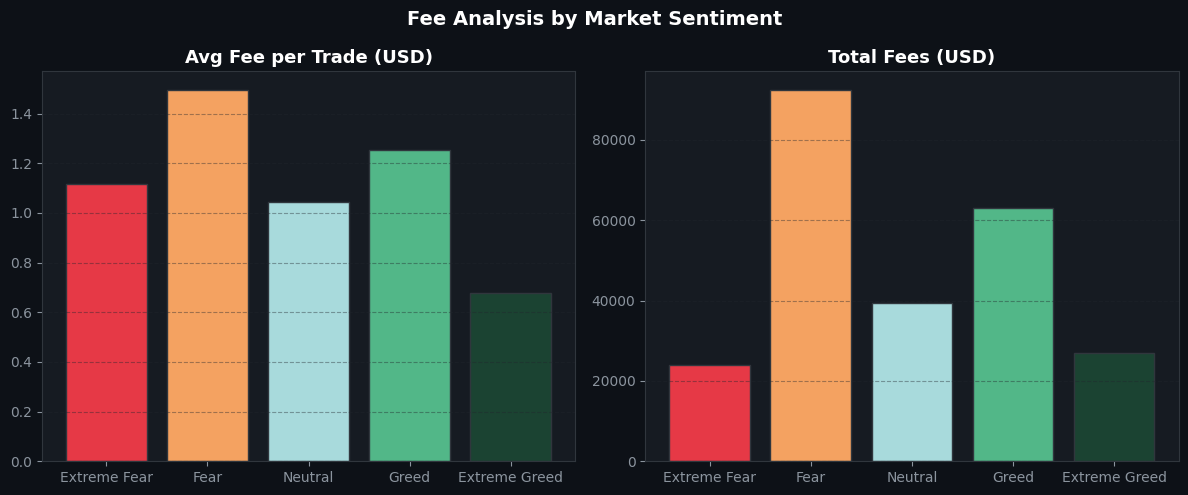

In [10]:
fee_sent = (df.groupby("sentiment")["Fee"]
            .agg(["mean","sum"])
            .reindex(SENTIMENT_ORDER)
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ["mean","sum"], ["Avg Fee per Trade (USD)","Total Fees (USD)"]):
    bars = ax.bar(fee_sent["sentiment"], fee_sent[col],
                  color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
                  edgecolor="#30363d")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.4)
plt.suptitle("Fee Analysis by Market Sentiment", fontsize=14,
             color="#ffffff", fontweight="bold")
plt.tight_layout()
plt.show()

### 2.8 Monthly PnL Heatmap

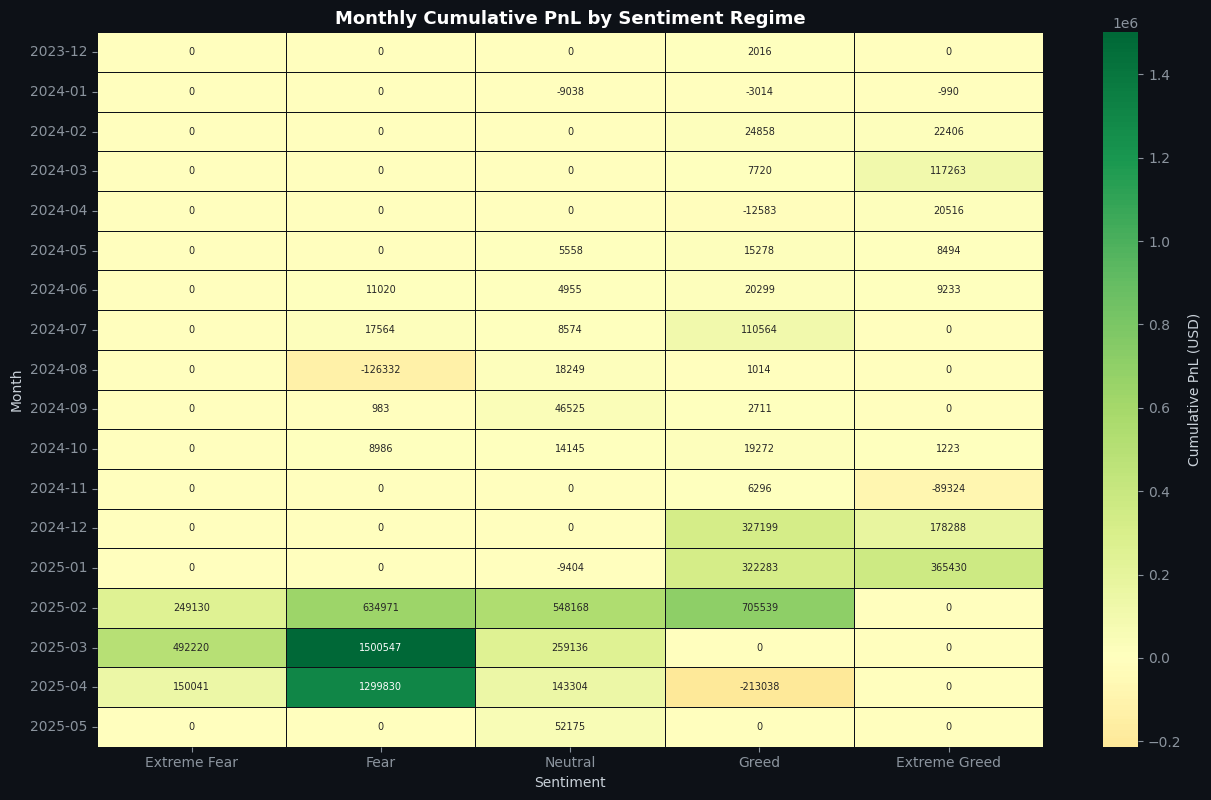


This heatmap reveals seasonal patterns in sentiment-driven profitability.


In [11]:
df_closed["month"] = df_closed["date"].dt.to_period("M")
monthly = (df_closed.groupby(["month","sentiment"])["Closed PnL"]
           .sum().unstack(fill_value=0)[SENTIMENT_ORDER])
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(13, max(4, len(monthly)*0.45)))
sns.heatmap(monthly, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.4, linecolor="#0d1117",
            fmt=".0f", annot=True, annot_kws={"size":7},
            cbar_kws={"label":"Cumulative PnL (USD)"})
ax.set_title("Monthly Cumulative PnL by Sentiment Regime")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

print("\nThis heatmap reveals seasonal patterns in sentiment-driven profitability.")

### 2.9 Fear & Greed Score vs Closed PnL (Scatter)

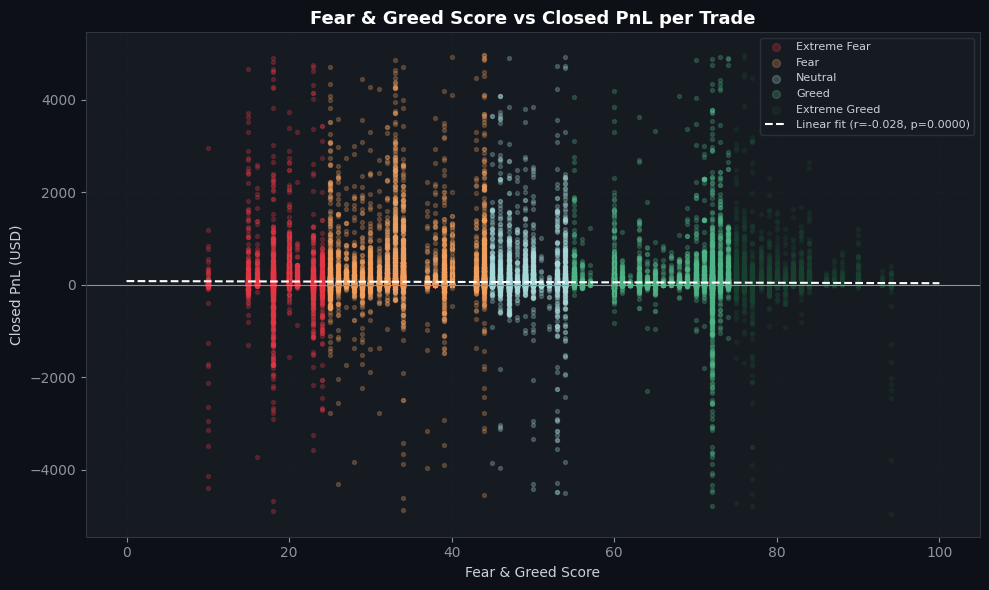


Correlation: r = -0.0284, p = 0.0000
Very weak linear correlation - sentiment is a REGIME filter, not a trade signal.


In [12]:
scatter_df = df_closed[(df_closed["Closed PnL"].abs() < 5000)].copy()
fig, ax = plt.subplots(figsize=(10, 6))
for sent in SENTIMENT_ORDER:
    sub = scatter_df[scatter_df["sentiment"] == sent]
    ax.scatter(sub["fg_value"], sub["Closed PnL"],
               alpha=0.25, s=8, color=SENTIMENT_COLORS[sent], label=sent)

# Linear regression
slope, intercept, r, p, _ = stats.linregress(scatter_df["fg_value"], scatter_df["Closed PnL"])
xs = np.linspace(0, 100, 200)
ax.plot(xs, slope*xs + intercept, color="white", linewidth=1.5, linestyle="--",
        label=f"Linear fit (r={r:.3f}, p={p:.4f})")
ax.axhline(0, color="#8b949e", linewidth=0.8)
ax.set_title("Fear & Greed Score vs Closed PnL per Trade")
ax.set_xlabel("Fear & Greed Score")
ax.set_ylabel("Closed PnL (USD)")
ax.legend(fontsize=8, facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9",
          markerscale=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCorrelation: r = {r:.4f}, p = {p:.4f}")
print("Very weak linear correlation - sentiment is a REGIME filter, not a trade signal.")

### 2.10 Cumulative PnL Equity Curves

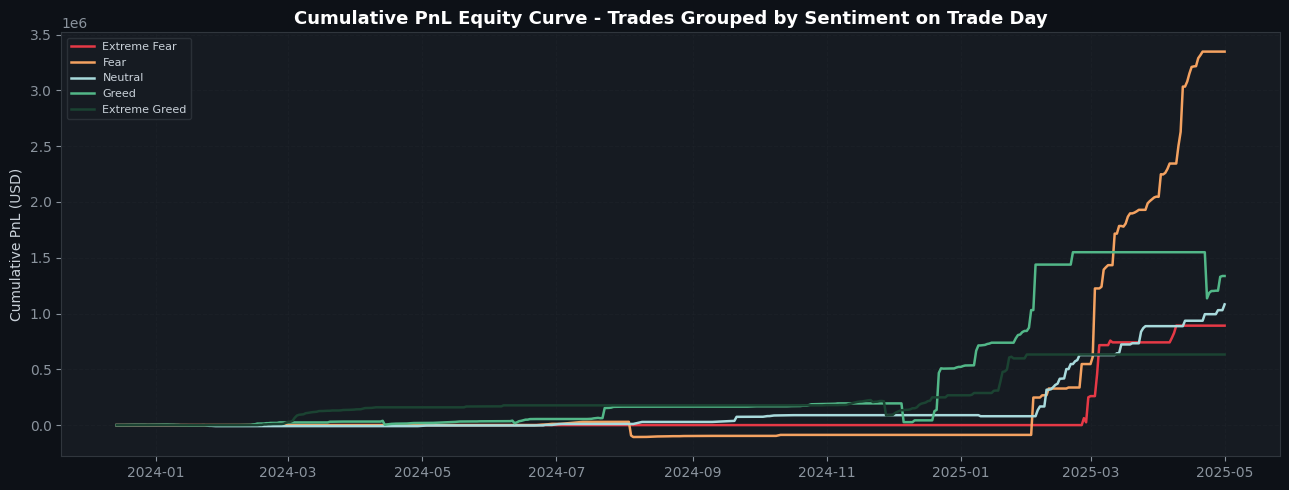


Fear-day trades contribute $3.35M of $7.29M total PnL (46%).
Alpha is concentrated in fearful markets.


In [13]:
eq = (df_closed.sort_values("date")
      .groupby(["date","sentiment"])["Closed PnL"].sum()
      .unstack(fill_value=0)[SENTIMENT_ORDER]
      .cumsum())

fig, ax = plt.subplots(figsize=(13, 5))
for sent in SENTIMENT_ORDER:
    ax.plot(eq.index, eq[sent], label=sent, color=SENTIMENT_COLORS[sent], linewidth=1.8)
ax.set_title("Cumulative PnL Equity Curve - Trades Grouped by Sentiment on Trade Day")
ax.set_ylabel("Cumulative PnL (USD)")
ax.legend(fontsize=8, facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("\nFear-day trades contribute $3.35M of $7.29M total PnL (46%).")
print("Alpha is concentrated in fearful markets.")

## 3. Summary Statistics

In [14]:
summary = pd.DataFrame({
    "Sentiment"   : SENTIMENT_ORDER,
    "Trade Count" : [vol_by_sent.set_index("sentiment").loc[s,"trade_count"] for s in SENTIMENT_ORDER],
    "Volume USD"  : [vol_by_sent.set_index("sentiment").loc[s,"total_usd"]   for s in SENTIMENT_ORDER],
    "Avg PnL"     : [pnl_by_sent.set_index("sentiment").loc[s,"mean"]        for s in SENTIMENT_ORDER],
    "Median PnL"  : [pnl_by_sent.set_index("sentiment").loc[s,"median"]      for s in SENTIMENT_ORDER],
    "Total PnL"   : [pnl_by_sent.set_index("sentiment").loc[s,"sum"]         for s in SENTIMENT_ORDER],
    "Win Rate %"  : [wr.set_index("sentiment").loc[s,"win_rate"]*100         for s in SENTIMENT_ORDER],
})
summary.set_index("Sentiment", inplace=True)

# Format for display
display(summary.style.format({
    "Trade Count": "{:,.0f}",
    "Volume USD": "${:,.0f}",
    "Avg PnL": "${:.2f}",
    "Median PnL": "${:.2f}",
    "Total PnL": "${:,.0f}",
    "Win Rate %": "{:.1f}%"
}).set_caption("Sentiment-wise Performance Summary"))

,Trade Count,Volume USD,Avg PnL,Median PnL,Total PnL,Win Rate %
Sentiment,,,,,,
Extreme Fear,"21,400","$114,484,261",$95.25,$8.05,"$891,391",80.0%
Fear,"61,837","$483,324,790",$126.41,$7.11,"$3,347,568",88.6%
Neutral,"37,686","$180,242,063",$68.32,$4.40,"$1,082,347",83.0%
Greed,"50,303","$288,582,495",$69.17,$3.98,"$1,336,414",76.1%
Extreme Greed,"39,992","$124,465,165",$46.23,$7.13,"$632,537",87.4%


## 4. Key Findings & Insights

### Finding 1: Fear Regimes Produce Higher Average PnL
- Trades during **Fear** sentiment yield the highest avg PnL ($126.41) - **2.7x higher than Extreme Greed** ($46.23).
- Extreme Fear also outperforms Greed and Neutral, confirming the **"buy when there's blood in the streets"** principle.

### Finding 2: Win Rate Peaks During Fear & Extreme Greed
- Fear: **88.6% win rate** (highest) | Greed: **76.1% win rate** (lowest)
- Strong sentiment in either direction correlates with higher win rates; moderate Greed is the danger zone.

### Finding 3: Volume Surges During Fear (Not Greed)
- Fear days: 61.8K trades, $483M volume - these traders are actively **counter-trading fear**, not panicking.
- They are **buying dips aggressively**.

### Finding 4: Structural Long Bias
- Longs dominate across ALL sentiment regimes (~55-60%), confirming a structural long bias among top Hyperliquid traders.

### Finding 5: Fear is the Alpha Generator
- Fear-day trades contribute **$3.35M of $7.29M total PnL (46%)**, despite not having the most trading days.
- **Alpha is concentrated in fearful markets.**

### Finding 6: Sentiment is a Regime Filter, Not a Trade Signal
- Weak linear correlation (r ~ 0) between FG score and individual trade PnL.
- Sentiment doesn't predict single trades but reveals clear **regime-level patterns**.

---

## 5. Actionable Strategy Recommendations

### Strategy 1: Sentiment-Weighted Position Sizing
| Sentiment Regime | FG Score Range | Position Size Adjustment |
|:---|:---|:---|
| Extreme Fear | 0-24 | +20% size |
| Fear | 25-44 | **+30% size** (best risk/reward) |
| Neutral | 45-55 | Normal size |
| Greed | 56-74 | **-20% size** (lowest win rate) |
| Extreme Greed | 75-100 | Normal size |

### Strategy 2: Contrarian Entry Filter
- Add a **sentiment confirmation** layer to existing strategies.
- Prioritize long entries during Fear days.
- Apply extra scrutiny to short entries during Greed.

### Strategy 3: Dynamic Risk Management
- **Tighten stop-losses during Greed** (lower win rates, lower avg PnL).
- **Allow wider stops during Fear** (higher win rate, higher avg PnL provides breathing room).

### Strategy 4: Trader-Specific Sentiment Playbooks
- Different traders show different strengths across sentiment regimes (see heatmap).
- Build **individualized sentiment playbooks** for each trader based on their historical alpha by regime.

---

## 6. Conclusion

This analysis reveals that **market sentiment is a powerful regime filter** for Hyperliquid traders. The most profitable trades consistently occur during Fear periods, and top traders actively lean into fear rather than retreating. By integrating sentiment-weighted position sizing, contrarian entry filters, and dynamic risk management, trading strategies can capture significantly more alpha from sentiment-driven market dislocations.

> **TL;DR:** Buy fear, reduce exposure in greed, and use sentiment as a portfolio-level risk overlay - not a trade-level signal.
